In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import sqlite3
from IPython.display import display

In [28]:
#Conectar con la base de datos y cargar tabla_analitica en un dataframe
sqlite_path = Path("../datos/intermedios/mercado_inmobiliario_bogota.sqlite")
conn = sqlite3.connect(sqlite_path)
df = pd.read_sql_query("SELECT * FROM tabla_analitica", conn)
df.head()

,name,neighborhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,precio_m2,precio_noche_Total,ingreso_anual,m2_estimados,costo_adquisicion,bedrooms_disc,bathrooms_disc,accommodates_disc,beds_disc,margen_bruto
0,ROOM IN LUXURIOUS DUPLEX APARTMENT,Barrios Unidos,4.684070,-74.05811,Private room,102706.0,3.0,365,"Cozy room y luxurious duplex apartment, balcon...",1,...,3572312,102706.0,2464944.0,50.0,178615600.0,1_hab,01_Uno,01_Uno,01_cama,1.38
1,Room near to everything you need in Bogotá!,Teusaquillo,4.625375,-74.07780,Private room,82261.0,4.0,222,My house is located in one of the most iconic ...,2,...,3986572,82261.0,658088.0,50.0,199328600.0,1_hab,01_Uno,02_Dos,01_cama,0.33
2,Hidden Gem with Private Garden & Quiet Workspace,Chapinero,4.675410,-74.04576,Entire home/apt,218392.0,1.0,327,"Loft with private Garden and Art, steps from ""...",3,...,4511746,218392.0,55689960.0,50.0,225587300.0,1_hab,01_Uno,03_Tres,02_camas,24.69
3,"Charming, cozy and luminous apartment in Rosales!",Chapinero,4.656870,-74.04920,Entire home/apt,270853.0,2.0,233,"This cozy, charming, quiet and luminous apartm...",2,...,4511746,270853.0,3250236.0,50.0,225587300.0,1_hab,01_Uno,02_Dos,01_cama,1.44
4,"900Mb Best Location Front To Biggest Park, Sal...",Barrios Unidos,4.662020,-74.08274,Entire home/apt,170363.0,30.0,189,"FREE Pick-up at the airport or bus terminal, F...",5,...,3572312,170363.0,20443560.0,65.0,232200280.0,2_hab,03_Dos,05_mas_cuatro,02_camas,8.80


In [29]:
dimensiones = ['neighborhood', 'room_type',
       'bedrooms_disc', 'bathrooms_disc',
       'accommodates_disc', 'beds_disc']

metricas = [ 'precio_noche_Total','estimated_occupancy_l365d', 'ingreso_anual', 'costo_adquisicion', 'margen_bruto']

In [30]:
#Seleccionar qué variables serán las métricas y cuáles las dimensiones, y construir la base inicial del minicubo.
minicubo_paso_1 = df[dimensiones + metricas].copy()
display(minicubo_paso_1.head())

,neighborhood,room_type,bedrooms_disc,bathrooms_disc,accommodates_disc,beds_disc,precio_noche_Total,estimated_occupancy_l365d,ingreso_anual,costo_adquisicion,margen_bruto
0,Barrios Unidos,Private room,1_hab,01_Uno,01_Uno,01_cama,102706.0,24,2464944.0,178615600.0,1.38
1,Teusaquillo,Private room,1_hab,01_Uno,02_Dos,01_cama,82261.0,8,658088.0,199328600.0,0.33
2,Chapinero,Entire home/apt,1_hab,01_Uno,03_Tres,02_camas,218392.0,255,55689960.0,225587300.0,24.69
3,Chapinero,Entire home/apt,1_hab,01_Uno,02_Dos,01_cama,270853.0,12,3250236.0,225587300.0,1.44
4,Barrios Unidos,Entire home/apt,2_hab,03_Dos,05_mas_cuatro,02_camas,170363.0,120,20443560.0,232200280.0,8.80


In [31]:
#Pasar a transaccional las dimensiones
minicubo_paso_2 = (
    minicubo_paso_1
    .melt(
        id_vars=metricas,
        value_vars=dimensiones,
        var_name='variable',
        value_name='value'
    )
    .dropna(subset=['value'])
)

display(minicubo_paso_2.head())

,precio_noche_Total,estimated_occupancy_l365d,ingreso_anual,costo_adquisicion,margen_bruto,variable,value
0,102706.0,24,2464944.0,178615600.0,1.38,neighborhood,Barrios Unidos
1,82261.0,8,658088.0,199328600.0,0.33,neighborhood,Teusaquillo
2,218392.0,255,55689960.0,225587300.0,24.69,neighborhood,Chapinero
3,270853.0,12,3250236.0,225587300.0,1.44,neighborhood,Chapinero
4,170363.0,120,20443560.0,232200280.0,8.80,neighborhood,Barrios Unidos


In [32]:
#Agregar las métricas por variable y valor
minicubo = (
    minicubo_paso_2
    .groupby(['variable', 'value'])[metricas]
    .median()
    .reset_index()
    .round(2)
)

display(minicubo)

,variable,value,precio_noche_Total,estimated_occupancy_l365d,ingreso_anual,costo_adquisicion,margen_bruto
0,accommodates_disc,01_Uno,91295.0,36.0,3236148.0,178615600.0,1.81
1,accommodates_disc,02_Dos,154059.0,60.0,8763477.0,199328600.0,4.65
2,accommodates_disc,03_Tres,171177.0,60.0,10236369.0,183365780.0,5.38
3,accommodates_disc,04_Cuatro,196283.0,72.0,14290752.0,199328600.0,7.12
4,accommodates_disc,05_mas_cuatro,262471.0,72.0,18203136.0,251020440.0,7.21
5,bathrooms_disc,01_Uno,158440.0,60.0,9476250.0,199328600.0,5.00
6,bathrooms_disc,03_Dos,241464.0,66.0,14950080.0,225587300.0,6.90
7,bathrooms_disc,03_Mas_de_dos,357273.0,60.0,16810458.0,293263490.0,5.37
8,bedrooms_disc,1_hab,160602.0,60.0,9428400.0,178615600.0,5.09
9,bedrooms_disc,2_hab,216710.0,66.0,14789664.0,229064940.0,6.68


# Analisis de tentabilidad

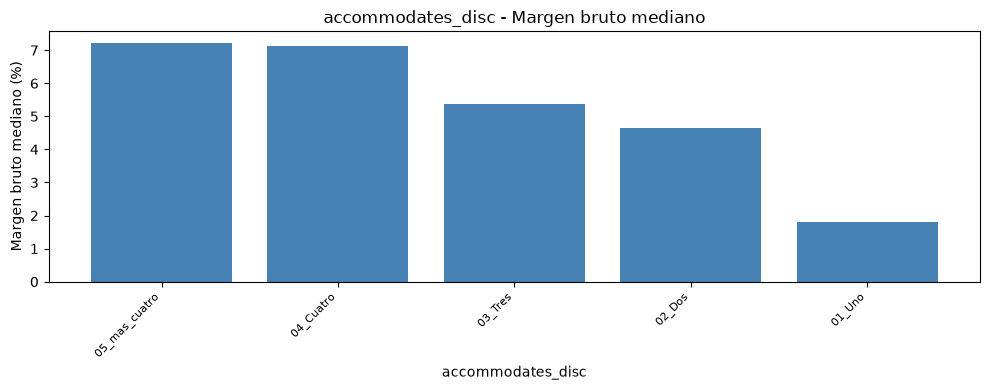

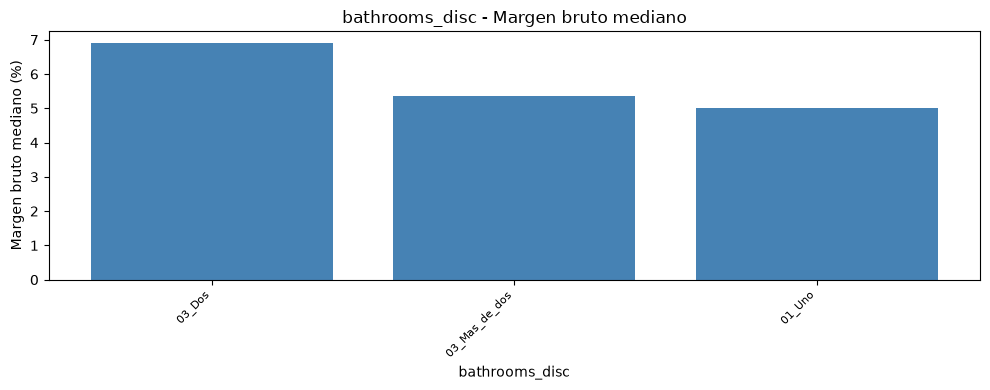

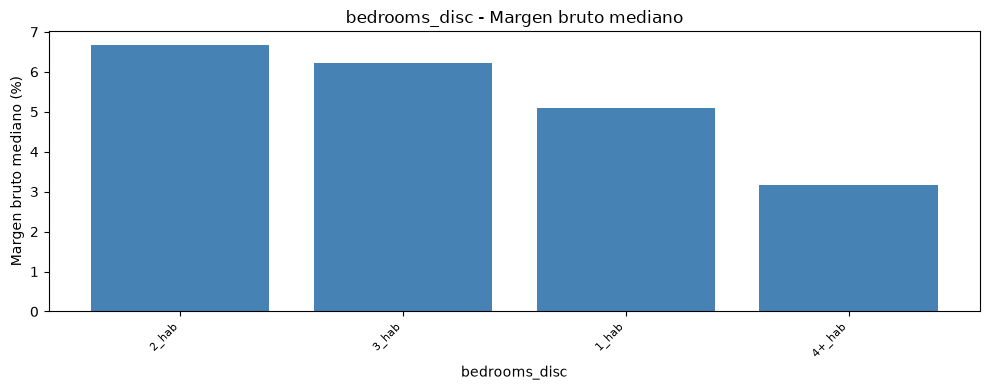

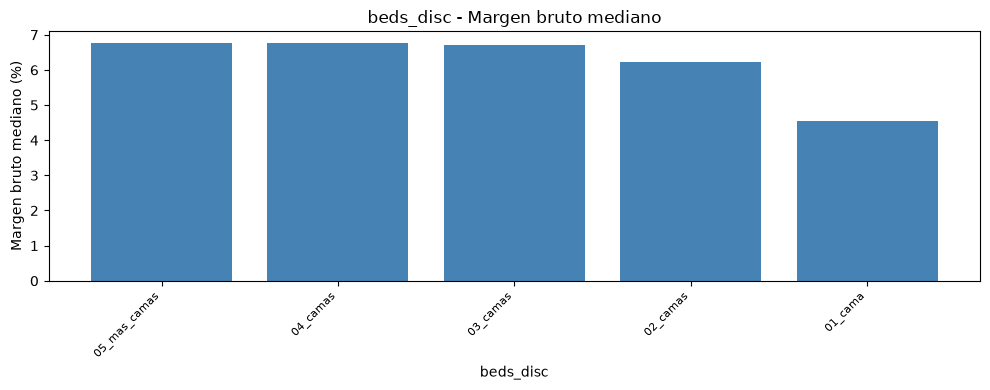

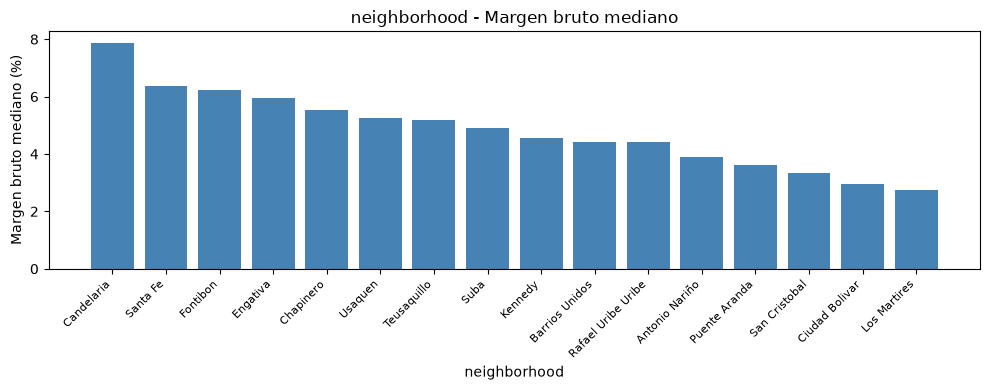

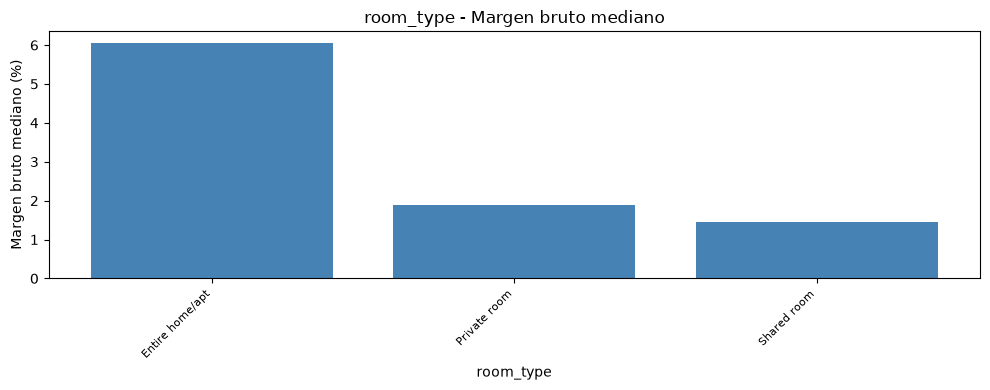

In [33]:
# Crear una gráfica del margen bruto mediano por cada dimensión
for dimension in minicubo["variable"].unique():
    
    datos = (
        minicubo[minicubo["variable"] == dimension]
        .sort_values("margen_bruto", ascending=False)
    )
    
    plt.figure(figsize=(10, 4))
    
    plt.bar(
        datos["value"].astype(str),
        datos["margen_bruto"],
        color="steelblue"
    )
    
    plt.title(f"{dimension} - Margen bruto mediano")
    plt.xlabel(dimension)
    plt.ylabel("Margen bruto mediano (%)")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

In [35]:
# Calcular indicadores del margen bruto
df_temp = df[["neighborhood", "estimated_occupancy_l365d", "margen_bruto"]].dropna().copy()

barrios_principales = (
    df_temp["neighborhood"]
    .value_counts()
    .head(10)
    .index.tolist()
)

margen_mediano = df_temp["margen_bruto"].median()
margen_media = df_temp["margen_bruto"].mean()
margen_minimo = df_temp["margen_bruto"].min()
margen_maximo = df_temp["margen_bruto"].max()
percentil_25 = df_temp["margen_bruto"].quantile(0.25)
percentil_75 = df_temp["margen_bruto"].quantile(0.75)

# Barrio con mayor margen bruto mediano
margen_por_barrio = (
    df_temp
    .groupby("neighborhood")["margen_bruto"]
    .median()
    .sort_values(ascending=False)
)

barrio_mayor_margen = margen_por_barrio.index[0]
valor_mayor_margen = margen_por_barrio.iloc[0]

print("INSIGHTS DEL ANÁLISIS")
print("---------------------")
print(f"Número de alojamientos analizados: {len(df_temp)}")
print(f"Barrios analizados: {', '.join(barrios_principales)}")
print(f"Margen bruto mediano: {margen_mediano:.2f}%")
print(f"Margen bruto medio: {margen_media:.2f}%")
print(f"Margen bruto mínimo: {margen_minimo:.2f}%")
print(f"Margen bruto máximo: {margen_maximo:.2f}%")
print(f"El 50% central de los datos está entre {percentil_25:.2f}% y {percentil_75:.2f}%")
print(
    f"El barrio con mayor margen bruto mediano es "
    f"{barrio_mayor_margen}, con un {valor_mayor_margen:.2f}%"
)

INSIGHTS DEL ANÁLISIS
---------------------
Número de alojamientos analizados: 8635
Barrios analizados: Chapinero, Usaquen, Teusaquillo, Santa Fe, Barrios Unidos, Engativa, Suba, Fontibon, Candelaria, Kennedy
Margen bruto mediano: 5.40%
Margen bruto medio: 8.32%
Margen bruto mínimo: 0.17%
Margen bruto máximo: 94.12%
El 50% central de los datos está entre 2.00% y 11.97%
El barrio con mayor margen bruto mediano es Candelaria, con un 7.88%


In [26]:
# Gráfico del margen bruto mediano por barrio
plt.figure(figsize=(10, 5))

margen_por_barrio.sort_values(ascending=False).plot(
    kind="bar",
    color="darkorange",
    edgecolor="black"
)

plt.title("Margen bruto mediano por barrio")
plt.xlabel("Barrio")
plt.ylabel("Margen bruto mediano (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'margen_por_barrio' is not defined

<Figure size 1000x500 with 0 Axes>

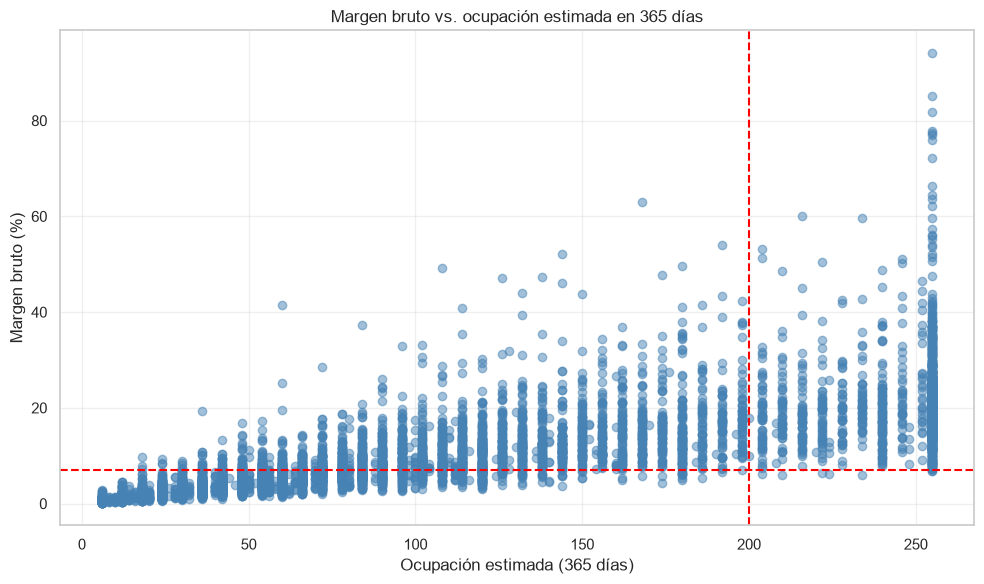

,estimated_occupancy_l365d,margen_bruto
2,255,24.69
28,240,12.86
38,255,8.66
43,252,21.99
58,255,15.85


Registros en el cuadrante objetivo: 1243


In [ ]:
# preparar los datos para el gráfico
df_temp = df[["estimated_occupancy_l365d", "margen_bruto"]].dropna().copy()

# gráfico de dispersión entre ocupación estimada y margen bruto
plt.figure(figsize=(10, 6))
plt.scatter(
    df_temp["estimated_occupancy_l365d"],
    df_temp["margen_bruto"],
    alpha=0.5,
    color="steelblue"
 )

plt.title("Margen bruto vs. ocupación estimada en 365 días")
plt.xlabel("Ocupación estimada (365 días)")
plt.ylabel("Margen bruto (%)")
plt.grid(alpha=0.3)

# líneas que delimitan el cuadrante objetivo
plt.axhline(y=7, color="red", linestyle="--", linewidth=1.5)
plt.axvline(x=200, color="red", linestyle="--", linewidth=1.5)

plt.tight_layout()
plt.show()

# obtener los registros con ocupación superior a 200 y margen bruto superior a 7
cuadrante_objetivo = df_temp[
    (df_temp["estimated_occupancy_l365d"] > 200)
    & (df_temp["margen_bruto"] > 7)
].copy()

display(cuadrante_objetivo.head())
print(f"Registros en el cuadrante objetivo: {len(cuadrante_objetivo)}")

# Analisis de ocupación 

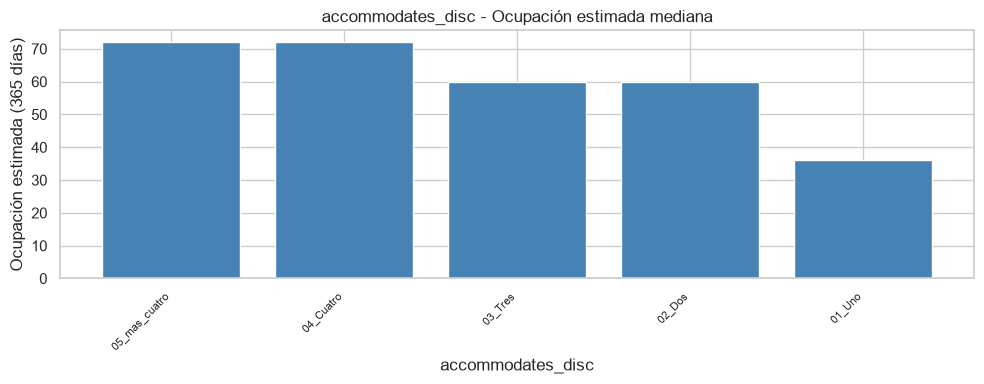

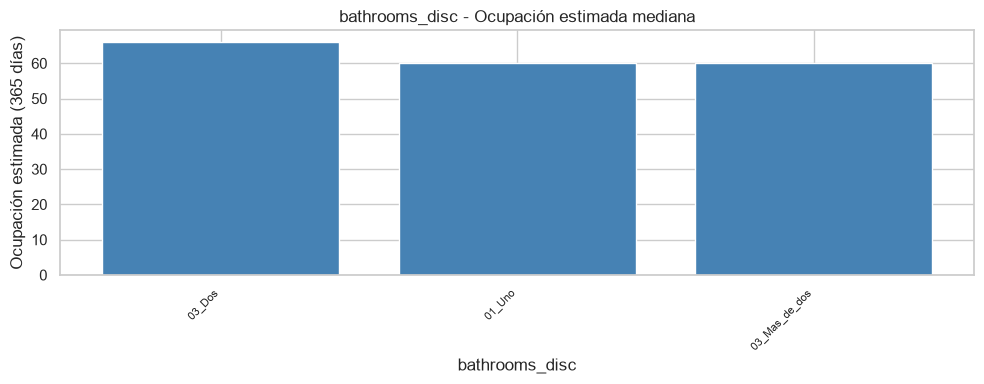

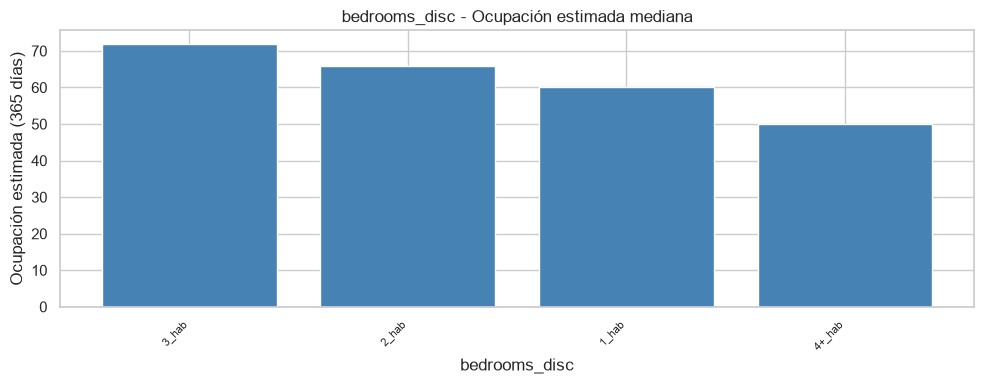

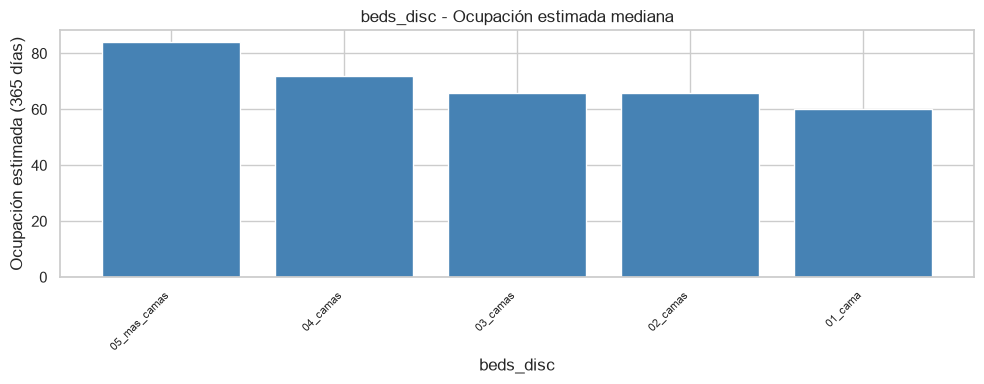

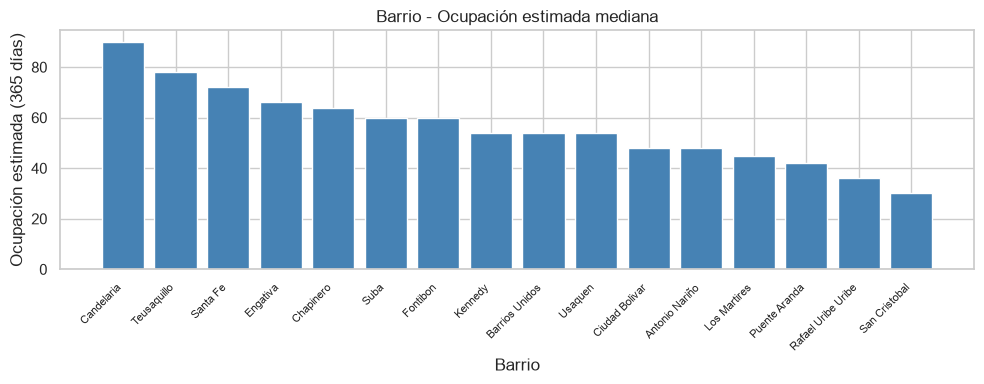

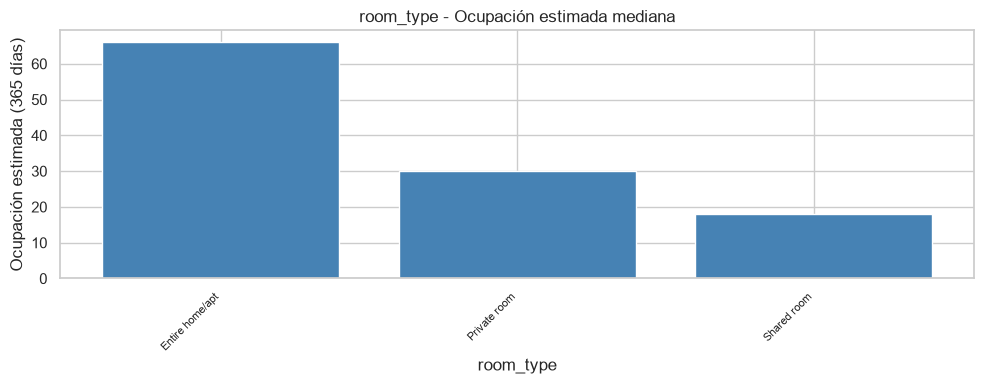

In [ ]:
# Gráficas de ocupación estimada mediana por dimensión
for dimension in minicubo["variable"].unique():
    datos = (
        minicubo[minicubo["variable"] == dimension]
        .sort_values("estimated_occupancy_l365d", ascending=False)
    )

    plt.figure(figsize=(10, 4))
    plt.bar(
        datos["value"].astype(str),
        datos["estimated_occupancy_l365d"],
        color="steelblue"
    )

    titulo_dimension = "Barrio" if dimension == "neighborhood" else dimension
    plt.title(f"{titulo_dimension} - Ocupación estimada mediana")
    plt.xlabel(titulo_dimension)
    plt.ylabel("Ocupación estimada (365 días)")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

# Donde Comprar

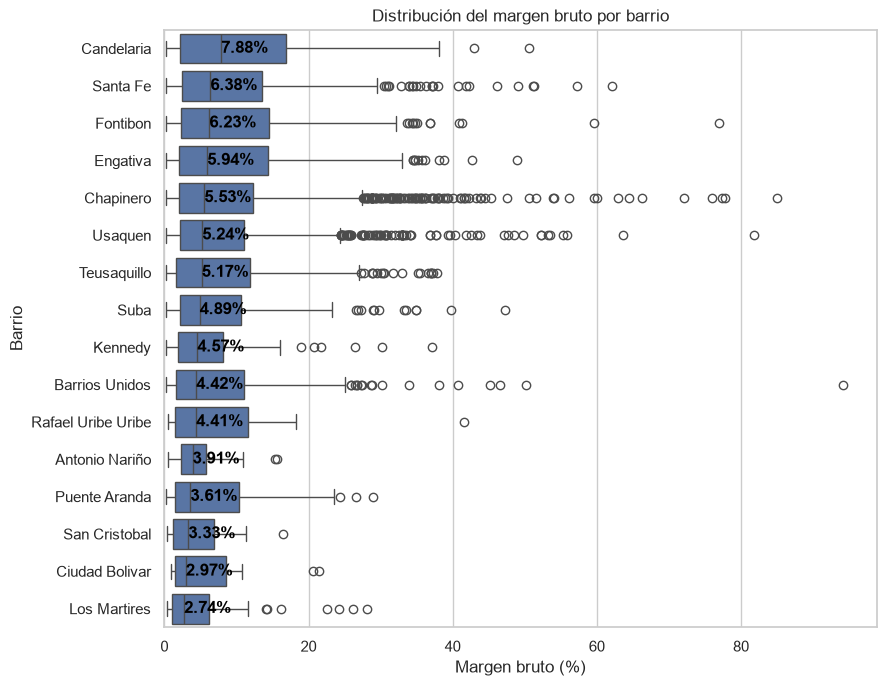

In [ ]:
# preparar los datos para el boxplot
df_boxplot = df[["neighborhood", "margen_bruto"]].dropna().copy()

# ordenar los barrios por margen bruto mediano, de mayor a menor
orden_barrios = (
    df_boxplot.groupby("neighborhood")["margen_bruto"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
 )

# boxplot horizontal del margen bruto por barrio
plt.figure(figsize=(10, 8))
ax = sns.boxplot(
    y="neighborhood",
    x="margen_bruto",
    data=df_boxplot,
    order=orden_barrios
 )

plt.title("Distribución del margen bruto por barrio")
plt.xlabel("Margen bruto (%)")
plt.ylabel("Barrio")
plt.xlim(left=0)
plt.tight_layout(pad=4)

# añadir la mediana como etiqueta en cada barrio
medianas = (
    df_boxplot.groupby("neighborhood")["margen_bruto"]
    .median()
    .reindex(orden_barrios)
 )

for i, barrio in enumerate(orden_barrios):
    valor_mediana = medianas.loc[barrio]
    ax.text(
        valor_mediana,
        i,
        f"{valor_mediana:.2f}%",
        va="center",
        ha="left",
        color="black",
        fontweight="bold"
    )

plt.show()

Barrios analizados: ['Teusaquillo', 'Santa Fe', 'Candelaria']


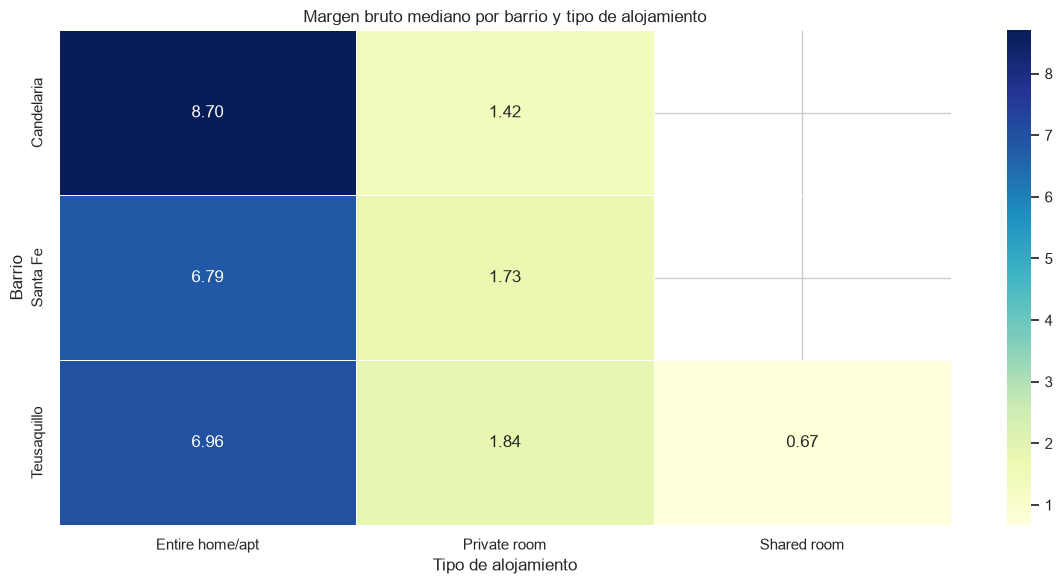

room_type,Entire home/apt,Private room,Shared room
neighborhood,,,
Candelaria,8.70,1.42,NaN
Santa Fe,6.79,1.72,NaN
Teusaquillo,6.96,1.84,0.67


In [ ]:
# Nivel 1: análisis de barrios prioritarios y tipo de alojamiento

# seleccionar los barrios de interés del proyecto
barrios_interes = ["Candelaria", "Santa Fe", "Teusaquillo"]

# filtrar los registros de esos barrios
df_seleccion = df[df["neighborhood"].isin(barrios_interes)].copy()

# comprobar qué barrios están realmente disponibles
barrios_disponibles = df_seleccion["neighborhood"].unique()
print("Barrios analizados:", list(barrios_disponibles))

# mapa de calor del margen bruto mediano por barrio y tipo de alojamiento
tabla_margen = df_seleccion.pivot_table(
    values="margen_bruto",
    index="neighborhood",
    columns="room_type",
    aggfunc="median"
 )

plt.figure(figsize=(12, 6))
sns.heatmap(
    tabla_margen,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
 )

plt.title("Margen bruto mediano por barrio y tipo de alojamiento")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()

# mostrar la tabla numérica con los resultados
tabla_margen.round(2)

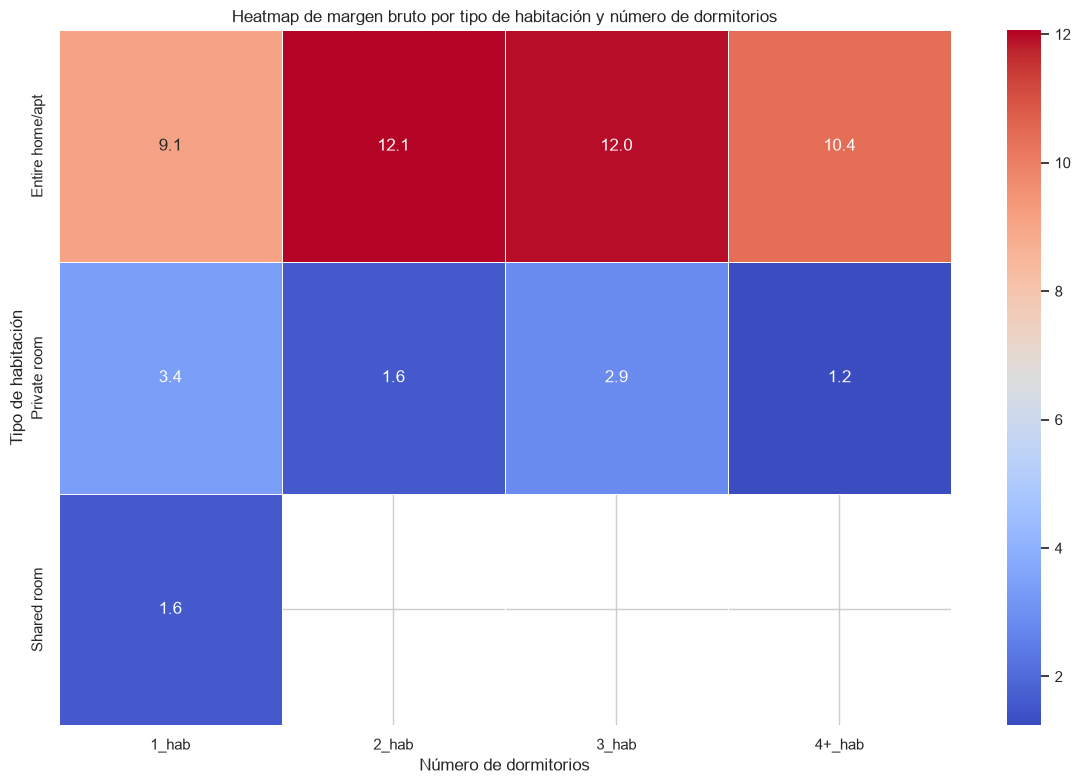

bedrooms_disc,1_hab,2_hab,3_hab,4+_hab
room_type,,,,
Entire home/apt,9.08,12.06,11.95,10.41
Private room,3.43,1.61,2.88,1.24
Shared room,1.61,NaN,NaN,NaN


In [ ]:
# heatmap del margen bruto por tipo de alojamiento y número de dormitorios

# usar la selección de barrios si existe; en caso contrario usar todo el dataset
base_df = df_seleccion.copy() if "df_seleccion" in globals() else df.copy()

tabla_heatmap = base_df.pivot_table(
    index="room_type",
    columns="bedrooms_disc",
    values="margen_bruto",
    aggfunc="mean"
 )

plt.figure(figsize=(12, 8))
sns.heatmap(
    tabla_heatmap,
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    linewidths=0.5
 )

plt.title("Heatmap de margen bruto por tipo de habitación y número de dormitorios")
plt.xlabel("Número de dormitorios")
plt.ylabel("Tipo de habitación")
plt.tight_layout()
plt.show()

tabla_heatmap.round(2)

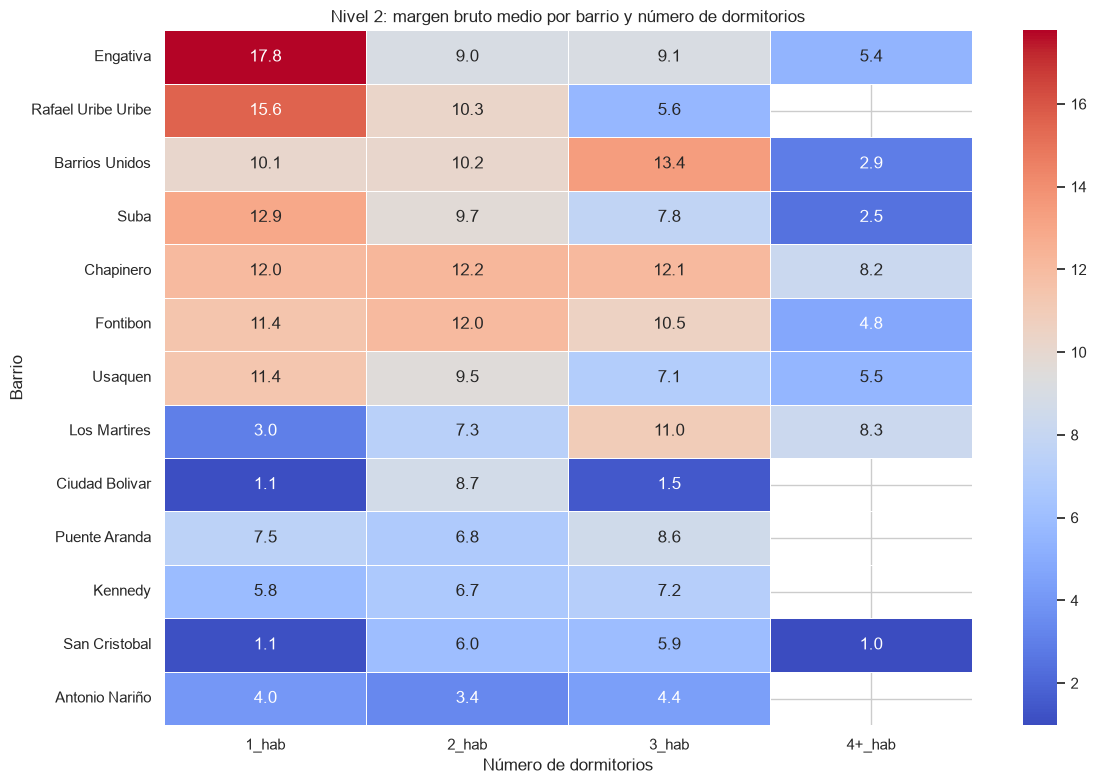

,neighborhood,bedrooms_disc,margen_bruto_medio
0,Engativa,1_hab,17.776410
4,Rafael Uribe Uribe,1_hab,15.580000
10,Barrios Unidos,3_hab,13.421000
12,Suba,1_hab,12.935909
17,Chapinero,2_hab,12.209598
18,Chapinero,3_hab,12.098172
21,Fontibon,2_hab,12.034286
16,Chapinero,1_hab,12.016545
20,Fontibon,1_hab,11.447179
24,Usaquen,1_hab,11.359866


Barrios analizados en el Nivel 2: 13


In [ ]:
# Nivel 2: qué comprar en el resto de los barrios

# excluir los barrios analizados en el Nivel 1
barrios_nivel_1 = ["Candelaria", "Santa Fe", "Teusaquillo"]

# filtrar viviendas completas con capacidad para 4 o más personas
df_nivel_2 = df[
    (~df["neighborhood"].isin(barrios_nivel_1))
    & (df["room_type"] == "Entire home/apt")
    & (df["accommodates"] >= 4)
].copy()

# conservar solo observaciones con las variables necesarias
df_nivel_2 = df_nivel_2.dropna(
    subset=["neighborhood", "bedrooms_disc", "margen_bruto"]
 )

# eliminar barrios con menos de 10 registros para reducir ruido
frecuencia_nivel_2 = df_nivel_2["neighborhood"].value_counts()
barrios_validos_nivel_2 = frecuencia_nivel_2[frecuencia_nivel_2 >= 10].index
df_nivel_2 = df_nivel_2[
    df_nivel_2["neighborhood"].isin(barrios_validos_nivel_2)
].copy()

# calcular el margen bruto medio por barrio y número de dormitorios
tabla_nivel_2 = df_nivel_2.pivot_table(
    index="neighborhood",
    columns="bedrooms_disc",
    values="margen_bruto",
    aggfunc="mean"
 )

# ordenar los barrios por su mejor combinación de dormitorios
orden_nivel_2 = tabla_nivel_2.max(axis=1).sort_values(ascending=False).index
tabla_nivel_2 = tabla_nivel_2.reindex(orden_nivel_2)

# heatmap de resultados
plt.figure(figsize=(12, 8))
sns.heatmap(
    tabla_nivel_2,
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    linewidths=0.5
 )

plt.title(
    "Nivel 2: margen bruto medio por barrio y número de dormitorios"
 )
plt.xlabel("Número de dormitorios")
plt.ylabel("Barrio")
plt.tight_layout()
plt.show()

# ranking de las mejores combinaciones barrio-dormitorios
ranking_nivel_2 = (
    tabla_nivel_2.stack()
    .reset_index(name="margen_bruto_medio")
    .sort_values("margen_bruto_medio", ascending=False)
 )

display(ranking_nivel_2.head(10))
print(f"Barrios analizados en el Nivel 2: {len(tabla_nivel_2)}")

,neighborhood,bedrooms_disc,accommodates_disc,margen_bruto_mediano,ocupacion_mediana,numero_registros
24,Engativa,1_hab,04_Cuatro,15.640,150.0,34
65,Suba,1_hab,04_Cuatro,14.420,114.0,39
13,Chapinero,1_hab,05_mas_cuatro,10.640,114.0,13
36,Fontibon,3_hab,05_mas_cuatro,10.140,78.0,40
17,Chapinero,3_hab,05_mas_cuatro,9.920,102.0,89
31,Fontibon,1_hab,04_Cuatro,9.730,66.0,36
14,Chapinero,2_hab,04_Cuatro,9.445,84.0,176
8,Barrios Unidos,2_hab,05_mas_cuatro,9.310,108.0,23
15,Chapinero,2_hab,05_mas_cuatro,8.270,78.0,147
29,Engativa,3_hab,05_mas_cuatro,7.750,78.0,27


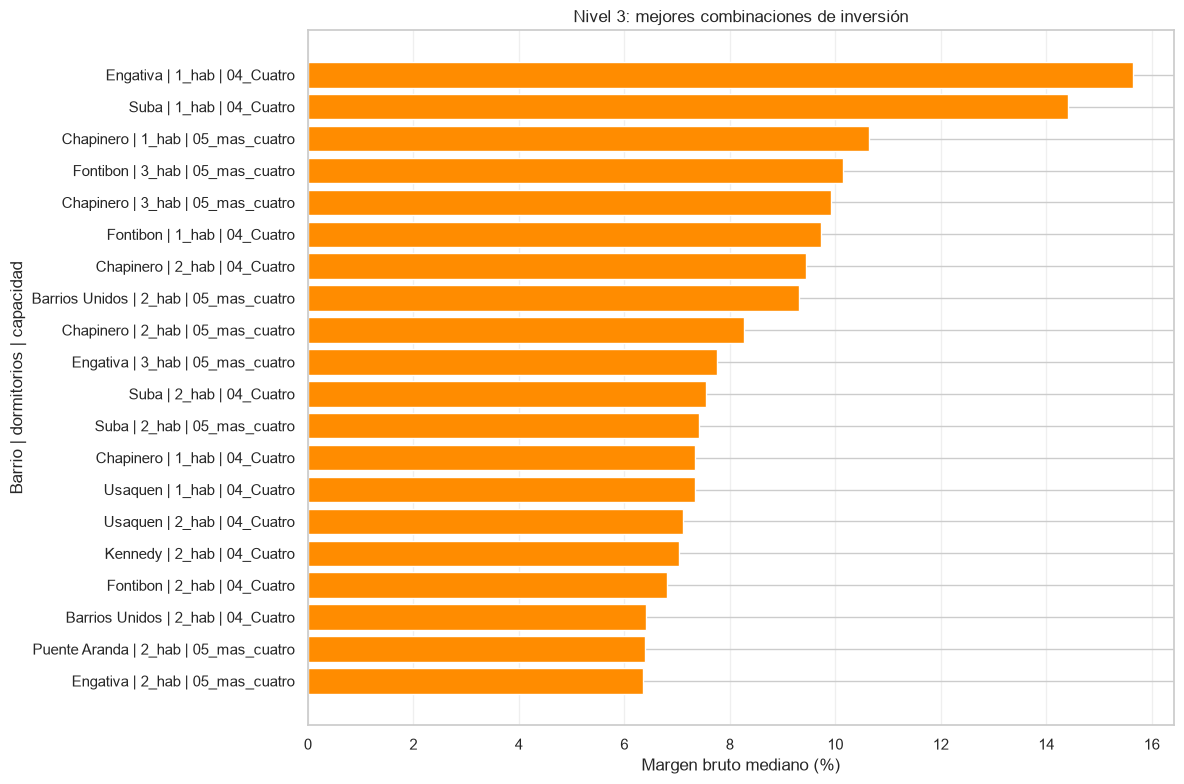

In [ ]:
# Nivel 3: análisis conjunto por barrio, dormitorios y capacidad

# usar el filtro estratégico del Nivel 2
df_nivel_3 = df_nivel_2.copy()

# agrupar las variables de decisión y calcular las métricas medianas
df_agrupado_nivel_3 = (
    df_nivel_3
    .groupby(["neighborhood", "bedrooms_disc", "accommodates_disc"])
    .agg(
        margen_bruto_mediano=("margen_bruto", "median"),
        ocupacion_mediana=("estimated_occupancy_l365d", "median"),
        numero_registros=("margen_bruto", "size")
    )
    .reset_index()
 )

# conservar combinaciones con al menos 10 registros
df_agrupado_nivel_3 = df_agrupado_nivel_3[
    df_agrupado_nivel_3["numero_registros"] >= 10
].copy()

# ordenar por margen bruto y mostrar las 20 mejores combinaciones
ranking_nivel_3 = (
    df_agrupado_nivel_3
    .sort_values(
        ["margen_bruto_mediano", "ocupacion_mediana"],
        ascending=False
    )
    .head(20)
 )

display(ranking_nivel_3)

# gráfico de las mejores combinaciones
ranking_nivel_3["combinacion"] = (
    ranking_nivel_3["neighborhood"]
    + " | "
    + ranking_nivel_3["bedrooms_disc"].astype(str)
    + " | "
    + ranking_nivel_3["accommodates_disc"].astype(str)
 )

plt.figure(figsize=(12, 8))
plt.barh(
    ranking_nivel_3["combinacion"].iloc[::-1],
    ranking_nivel_3["margen_bruto_mediano"].iloc[::-1],
    color="darkorange"
 )
plt.xlabel("Margen bruto mediano (%)")
plt.ylabel("Barrio | dormitorios | capacidad")
plt.title("Nivel 3: mejores combinaciones de inversión")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis grografico

In [ ]:
# Análisis geográfico: mapa de calor de rentabilidad

import folium
from folium.plugins import HeatMap
from IPython.display import display

# conservar registros con coordenadas y margen bruto válido
df_mapa = df.dropna(
    subset=["latitude", "longitude", "margen_bruto"]
 ).copy()
df_mapa = df_mapa[np.isfinite(df_mapa["margen_bruto"])]
df_mapa = df_mapa[df_mapa["margen_bruto"] >= 0]

# centro aproximado de Bogotá
bogota_coords = [4.7110, -74.0721]

# crear el mapa
mapa_rentabilidad = folium.Map(
    location=bogota_coords,
    zoom_start=11
 )

# preparar los puntos: latitud, longitud e intensidad del margen bruto
datos_calor = df_mapa[
    ["latitude", "longitude", "margen_bruto"]
].values.tolist()

HeatMap(
    datos_calor,
    radius=8,
    blur=15,
    max_zoom=13
 ).add_to(mapa_rentabilidad)

# mostrar el mapa dentro del notebook
display(mapa_rentabilidad)

# guardar el mapa como archivo HTML
ruta_mapa = "../entregables/graficos/mapa_rentabilidad.html"
mapa_rentabilidad.save(ruta_mapa)

print(f"Registros incluidos en el mapa: {len(df_mapa)}")
print(f"Mapa guardado en: {ruta_mapa}")

Registros incluidos en el mapa: 8635
Mapa guardado en: ../entregables/graficos/mapa_rentabilidad.html


In [ ]:
# Mapa de calor de ocupación estimada

# conservar registros con coordenadas y ocupación válida
df_mapa_ocupacion = df.dropna(
    subset=["latitude", "longitude", "estimated_occupancy_l365d"]
 ).copy()
df_mapa_ocupacion = df_mapa_ocupacion[np.isfinite(df_mapa_ocupacion["estimated_occupancy_l365d"])]
df_mapa_ocupacion = df_mapa_ocupacion[df_mapa_ocupacion["estimated_occupancy_l365d"] >= 0]

# crear el mapa centrado en Bogotá
mapa_ocupacion = folium.Map(
    location=bogota_coords,
    zoom_start=11
 )

# preparar los puntos: latitud, longitud e intensidad de ocupación
datos_ocupacion = df_mapa_ocupacion[
    ["latitude", "longitude", "estimated_occupancy_l365d"]
].values.tolist()

HeatMap(
    datos_ocupacion,
    radius=8,
    blur=15,
    max_zoom=13
 ).add_to(mapa_ocupacion)

# mostrar el mapa dentro del notebook
display(mapa_ocupacion)

# guardar el mapa como archivo HTML
ruta_mapa_ocupacion = "../entregables/graficos/mapa_ocupacion.html"
mapa_ocupacion.save(ruta_mapa_ocupacion)

print(f"Registros incluidos en el mapa: {len(df_mapa_ocupacion)}")
print(f"Mapa guardado en: {ruta_mapa_ocupacion}")

Registros incluidos en el mapa: 8635
Mapa guardado en: ../entregables/graficos/mapa_ocupacion.html


In [ ]:
# Mapa de oportunidades: alta rentabilidad y alta ocupación

import folium
from folium import CircleMarker
from IPython.display import display

# filtrar oportunidades del proyecto
df_oportunidades = df.dropna(
    subset=[
        "latitude",
        "longitude",
        "neighborhood",
        "margen_bruto",
        "estimated_occupancy_l365d"
    ]
 ).copy()

df_oportunidades = df_oportunidades[
    (df_oportunidades["margen_bruto"] > 20)
    & (df_oportunidades["estimated_occupancy_l365d"] > 200)
].copy()

# crear el mapa centrado en Bogotá
mapa_oportunidades = folium.Map(
    location=[4.7110, -74.0721],
    zoom_start=11
 )

# añadir un marcador por cada oportunidad
for _, fila in df_oportunidades.iterrows():
    popup = (
        f"<b>Barrio:</b> {fila['neighborhood']}<br>"
        f"<b>Rentabilidad:</b> {fila['margen_bruto']:.2f}%<br>"
        f"<b>Ocupación estimada:</b> {fila['estimated_occupancy_l365d']:.0f} días"
    )

    CircleMarker(
        location=[fila["latitude"], fila["longitude"]],
        radius=6,
        color="blue",
        fill=True,
        fill_color="yellow",
        fill_opacity=0.7,
        popup=popup
    ).add_to(mapa_oportunidades)

# mostrar el mapa dentro del notebook
display(mapa_oportunidades)

# guardar el mapa como archivo HTML
ruta_mapa_oportunidades = "../entregables/graficos/mapa_oportunidades.html"
mapa_oportunidades.save(ruta_mapa_oportunidades)

print(f"Oportunidades encontradas: {len(df_oportunidades)}")
print(f"Mapa guardado en: {ruta_mapa_oportunidades}")

Oportunidades encontradas: 599
Mapa guardado en: ../entregables/graficos/mapa_oportunidades.html
